# Step 3: Exploratory Data Analysis

## Objective

This notebook explores shipment exceptions using the cleaned order-level dataset.

It focuses on these business questions:

1. How many delivery exceptions occur?
2. What types of delivery exceptions occur most frequently?
3. How severe are late deliveries?
4. Which shipping modes have the highest exception rates?
5. In which markets are exceptions concentrated?
6. Which exception orders may need attention first?

Each calculation uses one row per order, so orders containing several items are not counted multiple times.


## 3.1 Load the Cleaned Dataset

The cleaned CSV created in Notebook 2 is loaded. Date columns are parsed as dates so they can be used for time analysis.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

clean_data_file = PROJECT_ROOT / "data" / "processed" / "dataco_orders_clean.csv"

orders = pd.read_csv(
    clean_data_file,
    parse_dates=["order_date", "shipping_date"]
)

print("Rows:", orders.shape[0])
print("Columns:", orders.shape[1])
print("Unique orders:", orders["order_id"].nunique())


Rows: 65752
Columns: 31
Unique orders: 65752


## 3.2 Overall Delivery Performance

The first overview calculates:

- Total orders
- Total delivery exceptions
- Delivery-exception rate
- Late orders and late-delivery rate
- Canceled shipping orders and cancellation rate

The exception definition used here is simple: late delivery or shipping canceled.


In [2]:
total_orders = len(orders)
exception_orders = orders["is_delivery_exception"].sum()
late_orders = (orders["delivery_status"] == "Late delivery").sum()
canceled_orders = (orders["delivery_status"] == "Shipping canceled").sum()

overall_kpis = pd.DataFrame({
    "KPI": [
        "Total Orders", "Delivery Exceptions", "Delivery Exception Rate",
        "Late Orders", "Late Delivery Rate",
        "Canceled Shipping Orders", "Cancellation Rate"
    ],
    "Value": [
        f"{total_orders:,}",
        f"{exception_orders:,}",
        f"{exception_orders / total_orders * 100:.2f}%",
        f"{late_orders:,}",
        f"{late_orders / total_orders * 100:.2f}%",
        f"{canceled_orders:,}",
        f"{canceled_orders / total_orders * 100:.2f}%"
    ]
})

display(overall_kpis)


,KPI,Value
0,Total Orders,"65,752"
1,Delivery Exceptions,"38,903"
2,Delivery Exception Rate,59.17%
3,Late Orders,"36,048"
4,Late Delivery Rate,54.82%
5,Canceled Shipping Orders,"2,855"
6,Cancellation Rate,4.34%


### Finding

The cleaned dataset contains 65,752 orders. A total of 38,903 orders (59.17%) are classified as delivery exceptions: 36,048 late deliveries and 2,855 canceled shipments. Late delivery is therefore the main contributor to the exception workload.


## 3.3 Delivery-Status Distribution

This chart compares all delivery outcomes. Counts and percentages are both included because a large count may simply reflect a large number of orders.


,Delivery Status,Order Count,Percentage
0,Late delivery,36048,54.82
1,Advance shipping,15127,23.01
2,Shipping on time,11722,17.83
3,Shipping canceled,2855,4.34


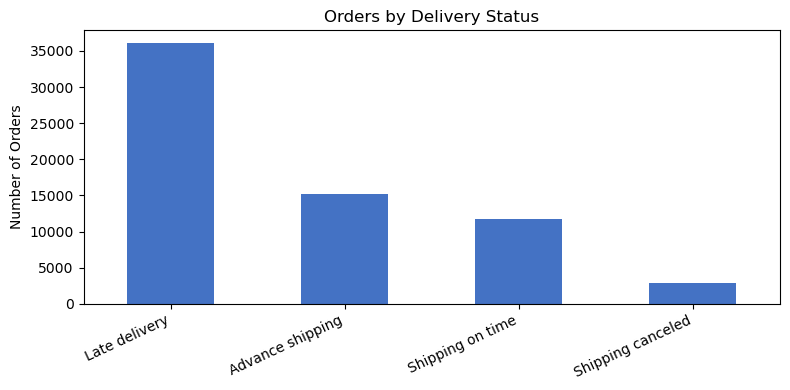

In [3]:
status_summary = (
    orders["delivery_status"]
    .value_counts()
    .rename_axis("Delivery Status")
    .reset_index(name="Order Count")
)

status_summary["Percentage"] = (
    status_summary["Order Count"] / total_orders * 100
).round(2)

display(status_summary)

ax = status_summary.plot.bar(
    x="Delivery Status",
    y="Order Count",
    legend=False,
    figsize=(8, 4),
    color="#4472C4"
)
ax.set_title("Orders by Delivery Status")
ax.set_xlabel("")
ax.set_ylabel("Number of Orders")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Finding

Late delivery is the most frequent delivery status at 54.82% of all orders. Shipping cancellation represents 4.34%. Advance shipping accounts for 23.01%, but it is not automatically treated as a harmful exception because the dataset does not show whether early arrival caused an operational problem.


## 3.4 Late-Delivery Severity

`delay_days` compares actual shipping time with scheduled shipping time:

```text
delay_days = actual shipping days - scheduled shipping days
```

- A positive value means the order was late.
- Zero means it matched the schedule.
- A negative value means it shipped earlier than scheduled.

Canceled shipments are excluded from the late-severity table because their delay value does not represent a completed delivery outcome.


,Days Late,Late Order Count,Percentage of Late Orders
0,1,21130,58.62
1,2,10010,27.77
2,3,2452,6.80
3,4,2456,6.81


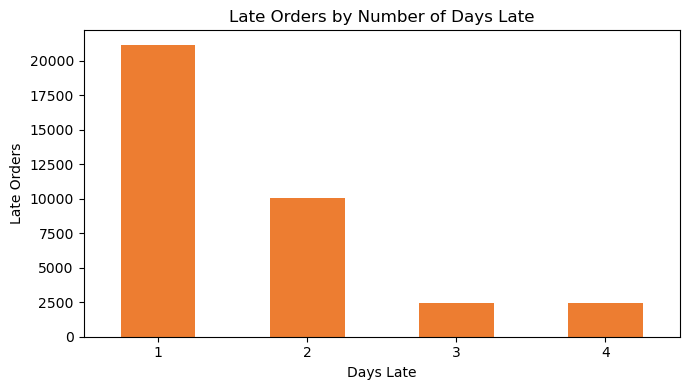

In [4]:
late_orders_df = orders[
    orders["delivery_status"] == "Late delivery"
].copy()

delay_summary = (
    late_orders_df["delay_days"]
    .value_counts()
    .sort_index()
    .rename_axis("Days Late")
    .reset_index(name="Late Order Count")
)

delay_summary["Percentage of Late Orders"] = (
    delay_summary["Late Order Count"] / len(late_orders_df) * 100
).round(2)

display(delay_summary)

ax = delay_summary.plot.bar(
    x="Days Late",
    y="Late Order Count",
    legend=False,
    figsize=(7, 4),
    color="#ED7D31"
)
ax.set_title("Late Orders by Number of Days Late")
ax.set_xlabel("Days Late")
ax.set_ylabel("Late Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Finding

Among late orders, 58.62% are one day late and 27.77% are two days late. The remaining 13.61% are three or four days late. This smaller group represents the most severe completed-delivery delays in the dataset.


## 3.5 Exceptions by Shipping Mode

This analysis uses **rates**, not only counts.

Exception count shows workload, while exception rate shows the proportion of orders that had an exception within each shipping mode.

Using only counts could make the most frequently used shipping mode appear worst simply because it handles more orders.


,shipping_mode,total_orders,exception_orders,late_orders,canceled_orders,exception_rate,late_rate,cancellation_rate
0,First Class,10079,10079,9602,477,100.00,95.27,4.73
2,Second Class,12778,10325,9803,522,80.80,76.72,4.09
1,Same Day,3571,1812,1648,164,50.74,46.15,4.59
3,Standard Class,39324,16687,14995,1692,42.43,38.13,4.30


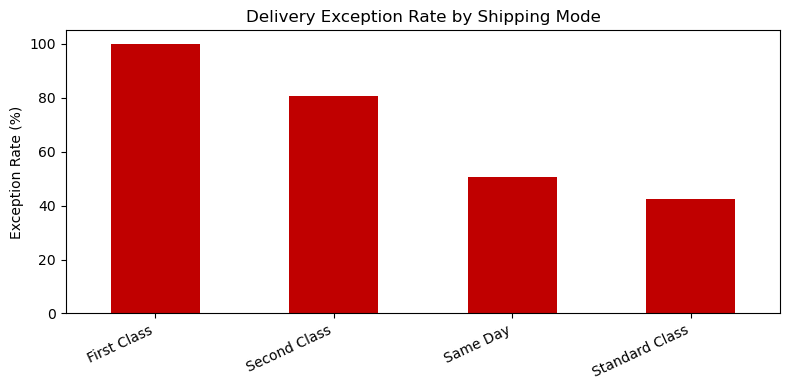

In [5]:
shipping_mode_summary = (
    orders.groupby("shipping_mode")
    .agg(
        total_orders=("order_id", "count"),
        exception_orders=("is_delivery_exception", "sum"),
        late_orders=("delivery_status", lambda values: (values == "Late delivery").sum()),
        canceled_orders=("delivery_status", lambda values: (values == "Shipping canceled").sum())
    )
    .reset_index()
)

shipping_mode_summary["exception_rate"] = (
    shipping_mode_summary["exception_orders"]
    / shipping_mode_summary["total_orders"] * 100
).round(2)

shipping_mode_summary["late_rate"] = (
    shipping_mode_summary["late_orders"]
    / shipping_mode_summary["total_orders"] * 100
).round(2)

shipping_mode_summary["cancellation_rate"] = (
    shipping_mode_summary["canceled_orders"]
    / shipping_mode_summary["total_orders"] * 100
).round(2)

shipping_mode_summary = shipping_mode_summary.sort_values(
    "exception_rate", ascending=False
)

display(shipping_mode_summary)

ax = shipping_mode_summary.plot.bar(
    x="shipping_mode",
    y="exception_rate",
    legend=False,
    figsize=(8, 4),
    color="#C00000"
)
ax.set_title("Delivery Exception Rate by Shipping Mode")
ax.set_xlabel("")
ax.set_ylabel("Exception Rate (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Finding

Shipping mode shows a strong difference in performance. First Class has a 100% delivery-exception rate in this dataset, including a 95.27% late-delivery rate. Standard Class has the lowest exception rate at 42.43%.

This is an association in the dataset, not proof that the shipping mode itself caused the delay. The pattern should be investigated further and should not be presented as an industry benchmark.


## 3.6 Exceptions by Market

Market-level exception rates show whether one broad destination market performs differently from another.

Both count and rate are retained:

- Count helps estimate operational workload.
- Rate allows a fairer performance comparison between markets of different sizes.


,market,total_orders,exception_orders,late_orders,canceled_orders,exception_rate,late_rate,cancellation_rate
4,USCA,8579,5105,4704,401,59.51,54.83,4.67
3,Pacific Asia,17577,10444,9720,724,59.42,55.30,4.12
1,Europe,18561,10997,10199,798,59.25,54.95,4.30
2,LATAM,17181,10106,9339,767,58.82,54.36,4.46
0,Africa,3854,2251,2086,165,58.41,54.13,4.28


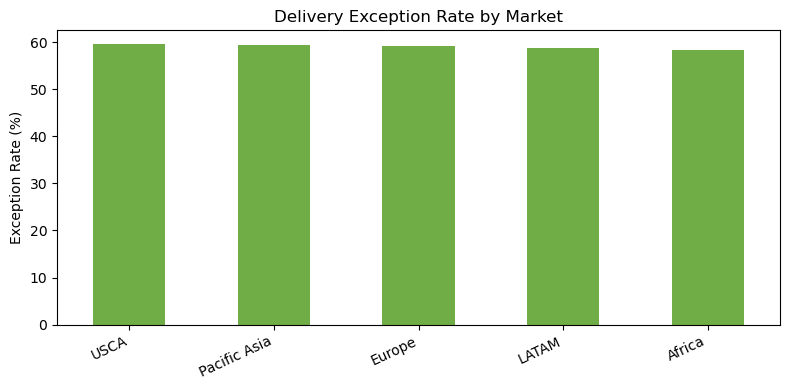

In [6]:
market_summary = (
    orders.groupby("market")
    .agg(
        total_orders=("order_id", "count"),
        exception_orders=("is_delivery_exception", "sum"),
        late_orders=("delivery_status", lambda values: (values == "Late delivery").sum()),
        canceled_orders=("delivery_status", lambda values: (values == "Shipping canceled").sum())
    )
    .reset_index()
)

market_summary["exception_rate"] = (
    market_summary["exception_orders"]
    / market_summary["total_orders"] * 100
).round(2)

market_summary["late_rate"] = (
    market_summary["late_orders"]
    / market_summary["total_orders"] * 100
).round(2)

market_summary["cancellation_rate"] = (
    market_summary["canceled_orders"]
    / market_summary["total_orders"] * 100
).round(2)

market_summary = market_summary.sort_values(
    "exception_rate", ascending=False
)

display(market_summary)

ax = market_summary.plot.bar(
    x="market",
    y="exception_rate",
    legend=False,
    figsize=(8, 4),
    color="#70AD47"
)
ax.set_title("Delivery Exception Rate by Market")
ax.set_xlabel("")
ax.set_ylabel("Exception Rate (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Finding

Market-level exception rates are very similar, ranging from 58.41% in Africa to 59.51% in USCA. This suggests that exceptions are broadly distributed across markets rather than being concentrated in one market at this level of analysis.


## 3.7 Monthly Exception Trend

This section checks whether delivery-exception performance changes over time.

The monthly exception rate is calculated as:

```text
monthly exception orders / monthly total orders × 100
```

The last months should be interpreted carefully if they contain only a small number of orders.


,order_year_month,total_orders,exception_orders,exception_rate
25,2017-02,1614,955,59.17
26,2017-03,1782,1056,59.26
27,2017-04,1739,990,56.93
28,2017-05,1763,1056,59.90
29,2017-06,1676,982,58.59
30,2017-07,1776,1049,59.07
31,2017-08,1768,1054,59.62
32,2017-09,1723,1024,59.43
33,2017-10,2101,1219,58.02
34,2017-11,2055,1231,59.90


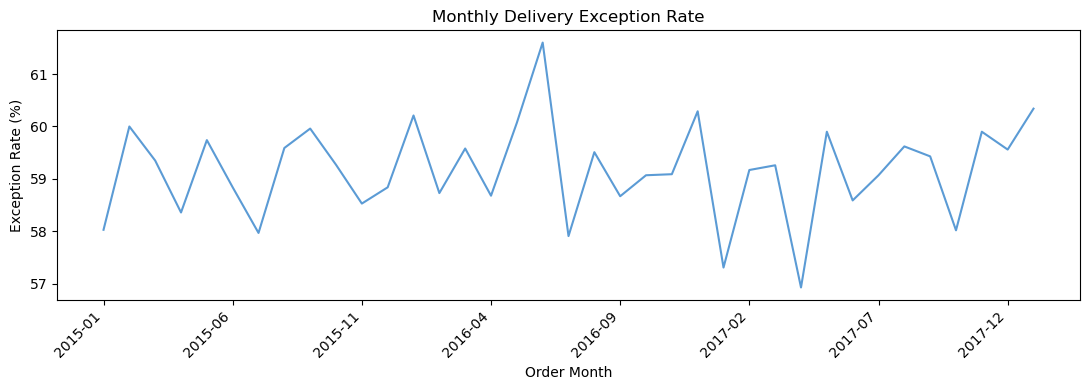

In [7]:
monthly_summary = (
    orders.groupby("order_year_month")
    .agg(
        total_orders=("order_id", "count"),
        exception_orders=("is_delivery_exception", "sum")
    )
    .reset_index()
)

monthly_summary["exception_rate"] = (
    monthly_summary["exception_orders"]
    / monthly_summary["total_orders"] * 100
).round(2)

display(monthly_summary.tail(12))

ax = monthly_summary.plot.line(
    x="order_year_month",
    y="exception_rate",
    legend=False,
    figsize=(11, 4),
    color="#5B9BD5"
)
ax.set_title("Monthly Delivery Exception Rate")
ax.set_xlabel("Order Month")
ax.set_ylabel("Exception Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Finding

Monthly exception rates remain relatively stable. The lowest monthly rate is approximately 56.93% and the highest is approximately 61.60%. There is no obvious large long-term improvement in exception performance.


## 3.8 Create a Simple Priority View

A Control Tower needs more than exception counts; it also needs a way to decide what to review first.

This beginner-level priority rule is transparent:

- **High:** shipping canceled, or a completed delivery that is at least 3 days late
- **Medium:** 2 days late
- **Low:** 1 day late
- **No Exception:** on time or advance shipping

This is an analytical starting rule, not a company SLA. A real business should adjust it using customer commitments, cost, and operational policies.


In [8]:
def assign_priority(row):
    if row["delivery_status"] == "Shipping canceled":
        return "High"
    if row["delivery_status"] == "Late delivery" and row["delay_days"] >= 3:
        return "High"
    if row["delivery_status"] == "Late delivery" and row["delay_days"] == 2:
        return "Medium"
    if row["delivery_status"] == "Late delivery" and row["delay_days"] == 1:
        return "Low"
    return "No Exception"

orders["priority_level"] = orders.apply(assign_priority, axis=1)

priority_order = ["High", "Medium", "Low", "No Exception"]

priority_summary = (
    orders["priority_level"]
    .value_counts()
    .reindex(priority_order, fill_value=0)
    .rename_axis("Priority Level")
    .reset_index(name="Order Count")
)

priority_summary["Order Value"] = priority_summary["Priority Level"].map(
    orders.groupby("priority_level")["order_value"].sum()
).round(2)

display(priority_summary)


,Priority Level,Order Count,Order Value
0,High,7763,"3,876,385.46"
1,Medium,10010,"5,027,673.01"
2,Low,21130,"10,588,234.13"
3,No Exception,26849,"13,562,109.78"


### Finding

The proposed rule classifies 7,763 orders as High priority, 10,010 as Medium, and 21,130 as Low. This creates a manageable operational view, but the thresholds remain a proposed business rule and should be confirmed with real service-level agreements.


## 3.9 High-Priority Exception Queue

The following table is a simple prototype of a Control Tower work queue.

Only operational fields are shown. Customer names, emails, passwords, and addresses are not included.

Within the high-priority group, orders are sorted first by delay and then by order value.


In [9]:
priority_queue_columns = [
    "order_id", "order_date", "market", "order_region", "order_country",
    "shipping_mode", "delivery_status", "order_status", "delay_days",
    "order_value", "order_profit", "priority_level"
]

high_priority_queue = (
    orders[orders["priority_level"] == "High"]
    [priority_queue_columns]
    .sort_values(
        ["delay_days", "order_value"],
        ascending=[False, False]
    )
)

print("High-priority orders:", len(high_priority_queue))
display(high_priority_queue.head(10))


High-priority orders: 7763


,order_id,order_date,market,order_region,order_country,shipping_mode,delivery_status,order_status,delay_days,order_value,order_profit,priority_level
18381,22030,2015-11-18 13:44:00,Pacific Asia,Eastern Asia,China,Second Class,Late delivery,PROCESSING,4,"1,839.62",317.46,High
43479,52160,2017-01-31 09:37:00,LATAM,Central America,El Salvador,Second Class,Late delivery,COMPLETE,4,"1,612.38",532.20,High
56834,68155,2017-09-21 21:22:00,Europe,Western Europe,Francia,Second Class,Late delivery,PENDING,4,"1,611.33",221.10,High
56241,67445,2017-09-11 12:38:00,Europe,Western Europe,Alemania,Second Class,Late delivery,PENDING_PAYMENT,4,"1,585.91",470.79,High
15626,18735,2015-10-01 11:21:00,Europe,Western Europe,Francia,Second Class,Late delivery,COMPLETE,4,"1,515.87",530.83,High
59052,70505,2017-10-26 04:41:00,Europe,Southern Europe,Italia,Second Class,Late delivery,PROCESSING,4,"1,485.00",103.95,High
63112,74565,2017-12-24 11:05:00,Pacific Asia,Southeast Asia,Indonesia,Second Class,Late delivery,PROCESSING,4,"1,485.00",683.10,High
17525,21015,2015-11-03 18:08:00,Pacific Asia,Southeast Asia,Filipinas,Second Class,Late delivery,PENDING,4,"1,484.15",305.28,High
47169,56555,2017-04-05 13:23:00,LATAM,Caribbean,República Dominicana,Second Class,Shipping canceled,CANCELED,4,"1,481.39",477.00,High
59087,70540,2017-10-26 16:57:00,Europe,Western Europe,Francia,Second Class,Late delivery,PENDING,4,"1,470.00",441.00,High


## Step 3 Conclusion

This EDA establishes the size and composition of the delivery-exception workload, compares performance across shipping modes and markets, examines delay severity and monthly trends, and creates a transparent first version of a priority queue.

Important caution: the results describe the DataCo dataset and should not be treated as industry benchmarks. The priority thresholds are an analytical proposal and should be validated against real business SLAs before operational use.
